# Activation Functions Exploration

This notebook provides a comprehensive analysis of activation functions within deep learning architectures.

- In this notebook we will understand various activation functions used withing deep learning architectures
- Analyze the mathematical properties and mechanics of each function in detail.
- Evaulate selection criteria

**Note**
1. For implementation look at custom logic written for intuition in `src/pytorch_fundamentals/activations`.
2. For verification of correct implementation you can look at `benchmarks/compare_activation_functions.ipynb`.

## Reusable code

Code written in the following cell will be used through out the notebook

In [1]:
import torch
import matplotlib.pyplot as plt

X = torch.arange(-50, 50, 0.1)


def plot_activation_graphs(function_name: str, input_tensor: torch.Tensor, function_output: torch.Tensor, gradient_output: torch.Tensor) -> None:
    """
    function to plot activation function and its first order derivative of it side by side.

    :param function_name: Function name's
    :param input_tensor: Original input tensor
    :param function_output: Output of the function's propagationn of a tensor
    :param gradient_output: Output of the function's gradient of a tensor

    :returns: None
    """

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Convert torch tensors to numpy array for them to be used by matplotlib object
    input_array = input_tensor.numpy()
    output_array = function_output.numpy()
    gradient_array = gradient_output.numpy()

    # Plot input vs activation function's output
    axes[0].plot(input_array, output_array)
    axes[0].set_title("Function Output")
    axes[0].set_xlabel("Input Tensor")
    axes[0].set_ylabel("Transformed Output")

    # Plot input vs activation function's gradient output
    axes[1].plot(input_array, gradient_array)
    axes[1].set_title("Gradient Output")
    axes[1].set_xlabel("Input Tensor")
    axes[1].set_ylabel("Gradient Value")

    # Add title describing which activation function this is for
    fig.suptitle(f"{function_name} Plots")

    plt.show()

%matplotlib inline    

## Sigmoid Non Linear Activation Function

### Overview
- The **Sigmoid** activation function (also known as the Logistic function) is one of the classic non-linearities used in deep learning, particularly in the early days of neural networks and currently in specific output layers.
- In classical Machine Learning, Sigmoid is most notably used in **Logistic Regression**

- The equation for sigmoid function is :- $\sigma(X) = \frac{1}{1 + e^{-X}}$ => $\sigma(X) = \frac{e^{X}}{1 + e^{X}}$ $\hspace{1cm} -eq^{n}(1)$ <br>

- This function is used to bound inputs that have their value falling in range ($-\infty$, $+\infty$) to an output falling in the range of (0, 1)

### Gradient Calculation
To use the function to update the weights we need to use it's first order differentiated value (it's **gradient**).

- Sigmoid function looks like $\frac{U}{V}$ where $U = e^{X}$ and $V = (1 + e^{X})$ <br>

- Differentiation rule for $\frac{U}{V}$ is $\frac{U'V - V'U}{V^2}$

So the calculation of gradient for sigmoid function is as follows:

$\sigma(X)' =  \frac{e^{X}}{1 + e^{X}}'$

$\sigma'(X) = \frac{(e^X)'(1 + e^X) - (e^X)(1 + e^X)'}{(1 + e^X)^2}$

$\sigma'(X) = \frac{(e^X)(1 + e^X) - (e^X)(e^X)}{(1 + e^X)^2}$

$\sigma'(X) = \frac{(e^X)(1 + e^X) - (e^X)(e^X)}{(1 + e^X)^2}$

$\sigma'(X) = \frac{e^X + e^{2X} - e^{2X}}{(1 + e^X)^2}$

$\sigma'(X) = \frac{e^X}{(1 + e^X)^2}$ $\hspace{9cm} -eq^{n}(2)$

We know that $\sigma(X) = \frac{e^{X}}{1 + e^{X}}$ from $eq^{n}(1)$ Therefore using $eq^{n}(1)$ and $eq^{n}(2)$ we get,

$\sigma'(X) = \sigma(X)(1 - \sigma(X))$ $\hspace{7.5cm} -eq^{n}(3)$

### Maximum value of gradient for sigmoid function
To know the maximum value of the gradient we need to different the gradient and equate it to 0.

Let $\sigma(X) = a$ we get $\sigma'(X) = a(1 - a)$ $\hspace{5.8cm} -eq^{n}(4)$

Differentiating $\sigma'(X)$ we get $\sigma''(X) = (a(1 - a))'$

$\sigma''(X) = 1 - 2a$ equating it to 0 we get $a = 0.5$

So at a=0.5 the maximum value of $\sigma'(X) = 0.25$ $\hspace{5cm} -eq^{n}(5)$


### Problem of vanishing gradients
Most deep learning architectures contain hundreds of layers. When the sigmoid function is used as the activation function in such deep networks, it can lead to the **vanishing gradient problem**.

From our derivation of maximum value of the gradient (**from equation 5**) we know that the derivative of the sigmoid function has a maximum value of only **0.25** and in most cases it is much smaller.

During backpropagation gradients are multiplied across layers. Since these gradient values lie in the range **(0, 1)** repeated multiplication causes them to shrink exponentially. In sigmoid function's case since the maximum value is 0.25 the gradients diminish much more rapidly as they propagate backward through the network.

As a result, layers closer to the input receive extremely small gradients or no gradients at all causing their weights to update very slowly or not at all. This makes learning inefficient in deep networks.

For this reason the sigmoid function is generally not suitable for deep architectures unless additional techniques (such as careful initialization or normalization methods) are used to mitigate the vanishing gradient issue.

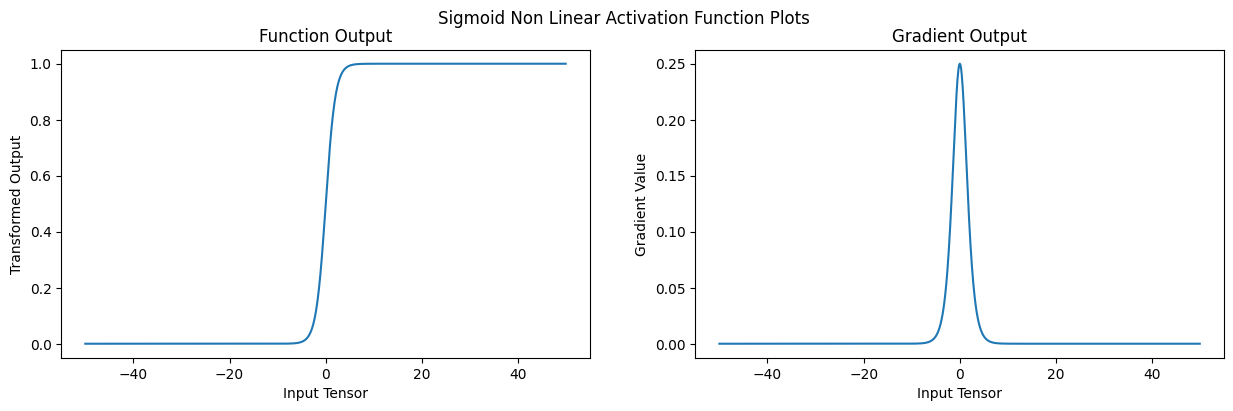

In [2]:
# Result of apply sigmoid non linear activation function on input tensor
function_output = torch.nn.Sigmoid().forward(X)
# Result of first order of differentiation of sigmoid function using input tensor
gradient_output = function_output * (1 - function_output)

# Plot results
plot_activation_graphs(function_name="Sigmoid Non Linear Activation Function",
                       input_tensor=X,
                       function_output=function_output,
                       gradient_output=gradient_output)